# ECS8051 CW2
### 40356093

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import time
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("All imports successful.")

All imports successful.


## 1. Regime Data Construction & Feature Engineering

In [2]:
df_raw = pd.read_csv('prices2.csv', parse_dates=['date'])
df_raw.columns = [c.lower() for c in df_raw.columns]

print(f"Data shape: {df_raw.shape}")
print(f"Date range: {df_raw['date'].min()} to {df_raw['date'].max()}")
print(f"Tickers: {df_raw['ticker'].unique()}")
df_raw.head()

Data shape: (22638, 8)
Date range: 2010-01-04 00:00:00 to 2024-12-30 00:00:00
Tickers: ['XLE' 'XLF' 'XLI' 'XLK' 'XLP' 'XLV']


,date,ticker,open,high,low,close,adj_close,volume
0,2010-01-04,XLE,57.919998,58.810001,57.790001,58.810001,35.058506,16928400
1,2010-01-05,XLE,58.889999,59.410000,58.619999,59.290001,35.344662,17368100
2,2010-01-06,XLE,59.320000,60.180000,59.189999,60.000000,35.767918,24351900
3,2010-01-07,XLE,59.740002,60.009998,59.299999,59.910000,35.714241,17449500
4,2010-01-08,XLE,59.700001,60.349998,59.490002,60.299999,35.946747,13344300


In [3]:
tickers = ['XLK', 'XLP', 'XLV', 'XLF', 'XLE', 'XLI']

df_close = df_raw.pivot(index='date', columns='ticker', values='close')[tickers]
df_high = df_raw.pivot(index='date', columns='ticker', values='high')[tickers]
df_low = df_raw.pivot(index='date', columns='ticker', values='low')[tickers]
df_volume = df_raw.pivot(index='date', columns='ticker', values='volume')[tickers]

# Forward fill missing values
df_close = df_close.ffill().bfill()
df_high = df_high.ffill().bfill()
df_low = df_low.ffill().bfill()
df_volume = df_volume.ffill().bfill()

print(f"Multivariate series shape: {df_close.shape}")
print(f"Missing values: {df_close.isna().sum().sum()}")
df_close.head()

Multivariate series shape: (3773, 6)
Missing values: 0


ticker,XLK,XLP,XLV,XLF,XLE,XLI
date,,,,,,
2010-01-04,23.270000,26.67,31.610001,11.933387,58.810001,28.320000
2010-01-05,23.240000,26.68,31.299999,12.152721,59.290001,28.420000
2010-01-06,22.980000,26.66,31.620001,12.177092,60.000000,28.480000
2010-01-07,22.889999,26.66,31.730000,12.437043,59.910000,28.790001
2010-01-08,23.040001,26.57,31.780001,12.363932,60.299999,29.250000


In [4]:
# Calculate log returns
df_returns = np.log(df_close / df_close.shift(1))
print(f"Returns shape: {df_returns.shape}")
df_returns.describe().round(4)

Returns shape: (3773, 6)


ticker,XLK,XLP,XLV,XLF,XLE,XLI
count,3772.0000,3772.0000,3772.0000,3772.0000,3772.0000,3772.0000
mean,0.0006,0.0003,0.0004,0.0004,0.0001,0.0004
std,0.0135,0.0087,0.0102,0.0140,0.0174,0.0123
min,-0.1487,-0.0987,-0.1038,-0.1474,-0.2249,-0.1204
25%,-0.0052,-0.0038,-0.0044,-0.0060,-0.0078,-0.0051
50%,0.0011,0.0006,0.0007,0.0007,0.0004,0.0008
75%,0.0073,0.0049,0.0058,0.0074,0.0086,0.0065
max,0.1109,0.0817,0.0742,0.1236,0.1487,0.1191


In [5]:
# Build features for regime detection using only past data
def build_regime_features(df_close, df_returns, df_high, df_low, df_volume, lookback=20):
    
    features = {}
    
    # Per ticker momentum and volatility
    for ticker in df_returns.columns:
        features[f'{ticker}_mom'] = df_returns[ticker].rolling(lookback, min_periods=lookback).mean()
        features[f'{ticker}_vol'] = df_returns[ticker].rolling(lookback, min_periods=lookback).std()
    
    # Market metrics
    features['avg_vol'] = df_returns.rolling(lookback, min_periods=lookback).std().mean(axis=1)
    features['dispersion'] = df_returns.std(axis=1).rolling(lookback, min_periods=lookback).mean()
    features['market_mom'] = df_returns.mean(axis=1).rolling(lookback, min_periods=lookback).mean()
    features['rolling_corr'] = df_returns.iloc[:, 0].rolling(lookback, min_periods=lookback).corr(df_returns.iloc[:, 1])
    
    # Volume features
    vol_ma = df_volume.rolling(lookback, min_periods=lookback).mean()
    features['avg_rel_vol'] = (df_volume / vol_ma).mean(axis=1)
    
    # ATR normalised
    tr = pd.DataFrame(index=df_close.index)
    for ticker in df_close.columns:
        hl = df_high[ticker] - df_low[ticker]
        hc = abs(df_high[ticker] - df_close[ticker].shift(1))
        lc = abs(df_low[ticker] - df_close[ticker].shift(1))
        tr[ticker] = pd.concat([hl, hc, lc], axis=1).max(axis=1)
    atr = tr.rolling(lookback, min_periods=lookback).mean()
    features['avg_atr'] = (atr / df_close).mean(axis=1)
    
    df_features = pd.DataFrame(features, index=df_returns.index)
    return df_features.dropna()

LOOKBACK = 20
df_regime_features = build_regime_features(df_close, df_returns, df_high, df_low, df_volume, lookback=LOOKBACK)

print(f"Regime features shape: {df_regime_features.shape}")
print(f"Features: {df_regime_features.columns.tolist()}")
print(f"Date range: {df_regime_features.index.min()} to {df_regime_features.index.max()}")

Regime features shape: (3753, 18)
Features: ['XLK_mom', 'XLK_vol', 'XLP_mom', 'XLP_vol', 'XLV_mom', 'XLV_vol', 'XLF_mom', 'XLF_vol', 'XLE_mom', 'XLE_vol', 'XLI_mom', 'XLI_vol', 'avg_vol', 'dispersion', 'market_mom', 'rolling_corr', 'avg_rel_vol', 'avg_atr']
Date range: 2010-02-02 00:00:00 to 2024-12-30 00:00:00


In [6]:
print("Summary Statistics of Regime Features:")
df_regime_features[['avg_vol', 'market_mom', 'dispersion', 'rolling_corr', 'avg_rel_vol', 'avg_atr']].describe().round(4)

Summary Statistics of Regime Features:


,avg_vol,market_mom,dispersion,rolling_corr,avg_rel_vol,avg_atr
count,3753.0000,3753.0000,3753.0000,3753.0000,3753.0000,3753.0000
mean,0.0110,0.0004,0.0066,0.5048,1.0082,0.0154
std,0.0060,0.0022,0.0025,0.2975,0.3128,0.0073
min,0.0043,-0.0223,0.0028,-0.5099,0.2188,0.0072
25%,0.0077,-0.0006,0.0049,0.3017,0.8050,0.0112
50%,0.0096,0.0006,0.0060,0.5696,0.9545,0.0134
75%,0.0127,0.0016,0.0076,0.7445,1.1510,0.0174
max,0.0686,0.0111,0.0249,0.9688,3.8655,0.0917


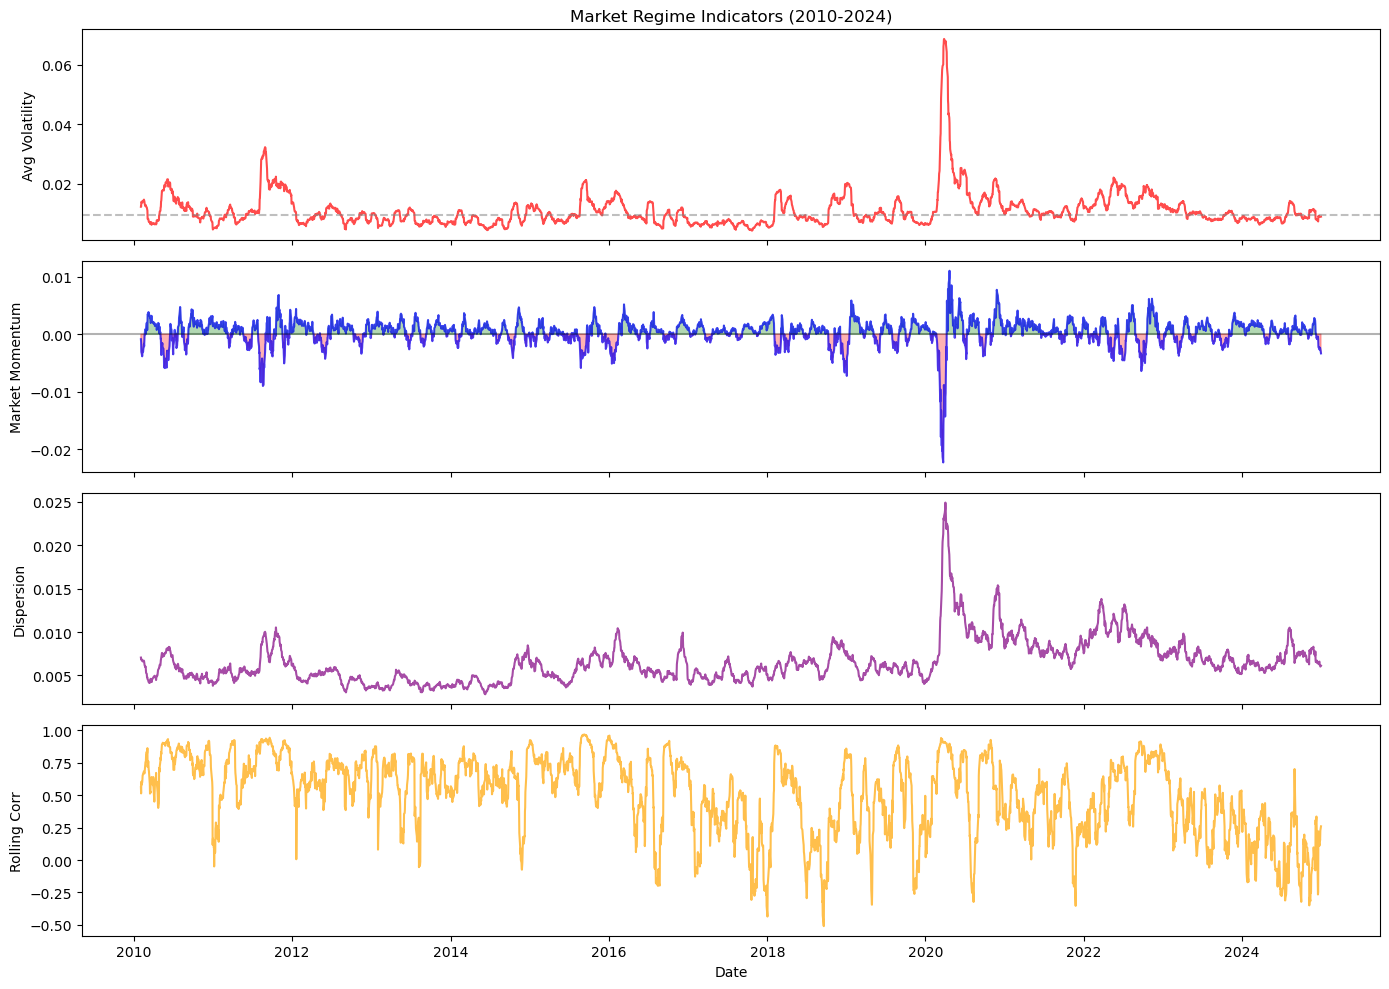

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df_regime_features.index, df_regime_features['avg_vol'], color='red', alpha=0.7)
axes[0].set_ylabel('Avg Volatility')
axes[0].set_title('Market Regime Indicators (2010-2024)')
axes[0].axhline(y=df_regime_features['avg_vol'].median(), color='gray', linestyle='--', alpha=0.5)

axes[1].plot(df_regime_features.index, df_regime_features['market_mom'], color='blue', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1].set_ylabel('Market Momentum')
axes[1].fill_between(df_regime_features.index, 0, df_regime_features['market_mom'],
                     where=df_regime_features['market_mom'] > 0, color='green', alpha=0.3)
axes[1].fill_between(df_regime_features.index, 0, df_regime_features['market_mom'],
                     where=df_regime_features['market_mom'] < 0, color='red', alpha=0.3)

axes[2].plot(df_regime_features.index, df_regime_features['dispersion'], color='purple', alpha=0.7)
axes[2].set_ylabel('Dispersion')

axes[3].plot(df_regime_features.index, df_regime_features['rolling_corr'], color='orange', alpha=0.7)
axes[3].set_ylabel('Rolling Corr')
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.show()

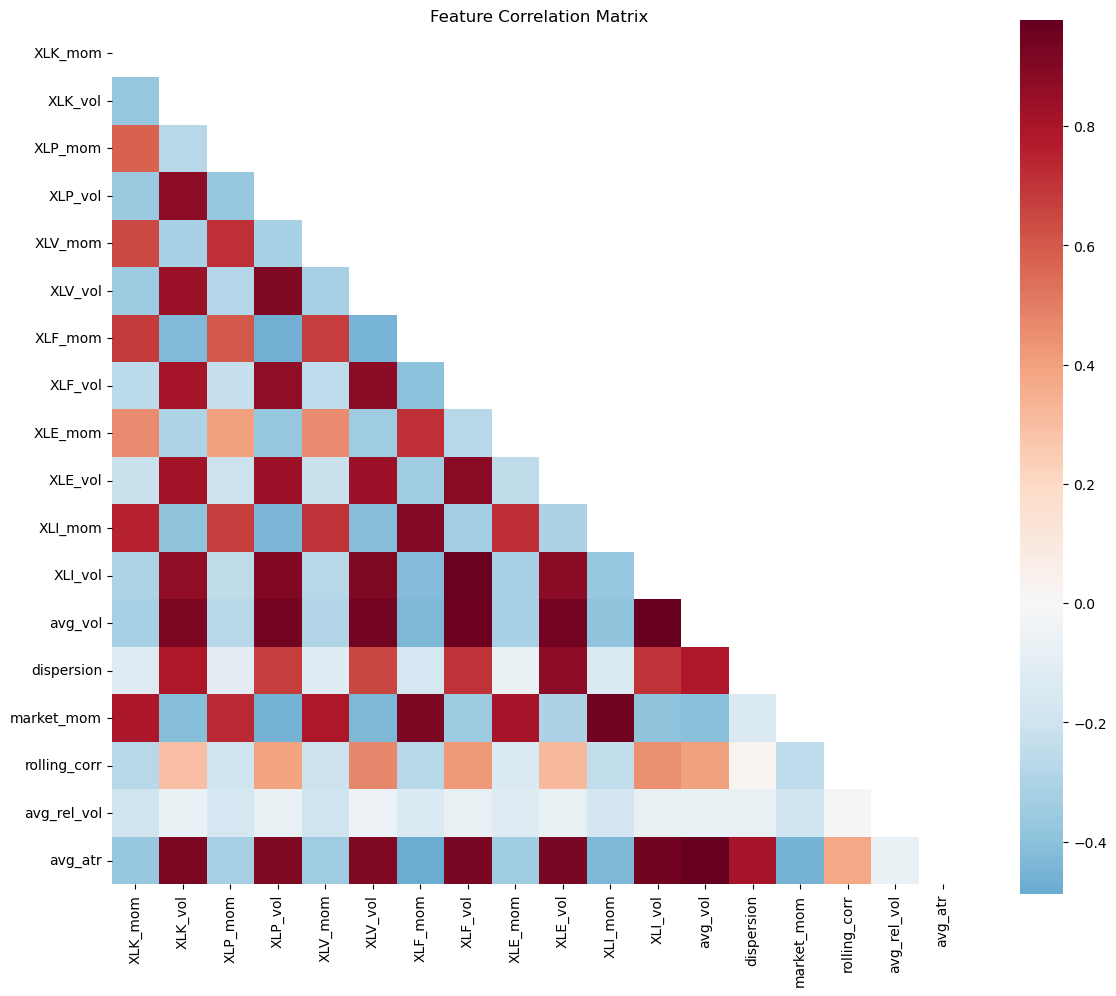

In [8]:
plt.figure(figsize=(12, 10))
corr_matrix = df_regime_features.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

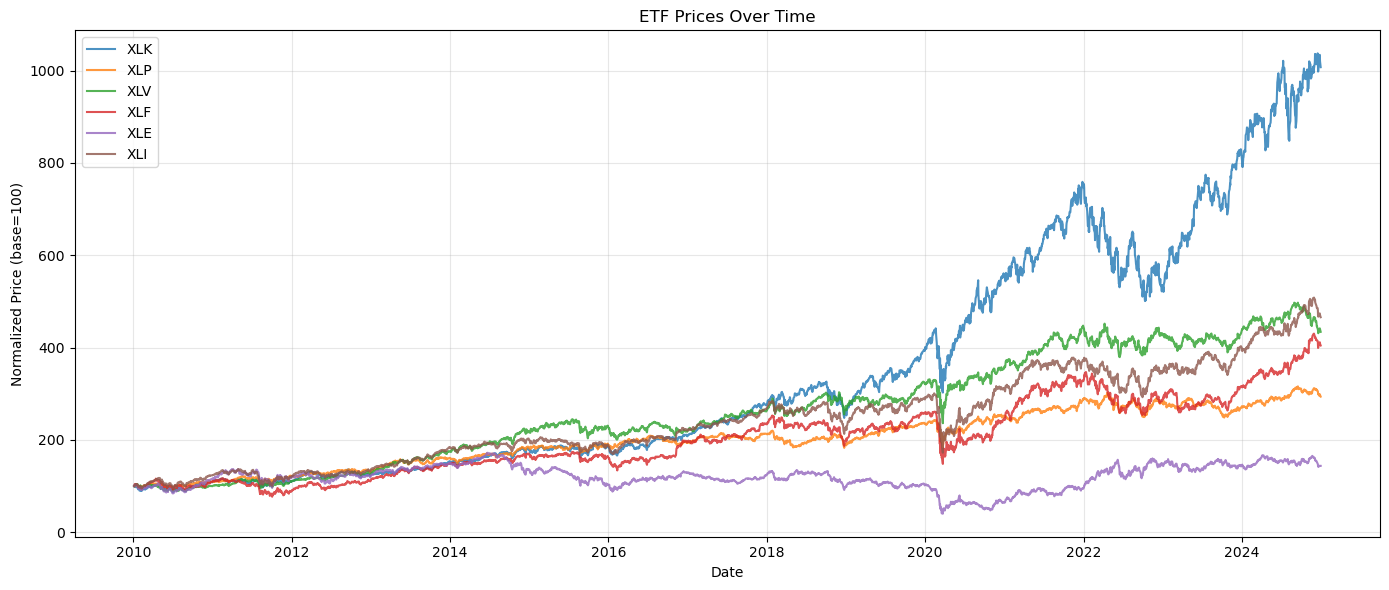

In [9]:
# Normalised price plot
plt.figure(figsize=(14, 6))
for ticker in tickers:
    normalized = df_close[ticker] / df_close[ticker].iloc[0] * 100
    plt.plot(df_close.index, normalized, label=ticker, alpha=0.8)
plt.xlabel('Date')
plt.ylabel('Normalized Price (base=100)')
plt.title('ETF Prices Over Time')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('price_series.png', dpi=150)
plt.show()

In [10]:
# Train/All split for regime discovery
regime_start = df_regime_features.index.min()
regime_train_end = regime_start + pd.DateOffset(years=4)  # first 4 years

df_regime_train = df_regime_features.loc[:regime_train_end]
df_regime_all   = df_regime_features

print(f"Regime training window: {df_regime_train.index.min()} to {df_regime_train.index.max()}")
print(f"Regime full window:     {df_regime_all.index.min()} to {df_regime_all.index.max()}")

# Fit scaler on train regime window only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(df_regime_train)

# Apply trained scaler to all dates
X_all_scaled = scaler.transform(df_regime_all)

# Fit PCA on train only
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform all dates into PCA
X_all_pca = pca.transform(X_all_scaled)

print(f"Original features: {X_all_scaled.shape[1]}")
print(f"PCA components (95% variance): {X_all_pca.shape[1]}")
print(f"Explained variance ratio (train): {pca.explained_variance_ratio_.round(3)}")
print(f"Cumulative variance (train): {np.cumsum(pca.explained_variance_ratio_).round(3)}")


Regime training window: 2010-02-02 00:00:00 to 2014-01-31 00:00:00
Regime full window:     2010-02-02 00:00:00 to 2024-12-30 00:00:00
Original features: 18
PCA components (95% variance): 7
Explained variance ratio (train): [0.595 0.214 0.052 0.037 0.033 0.019 0.013]
Cumulative variance (train): [0.595 0.809 0.861 0.898 0.93  0.949 0.962]


## 2. Clustering Methodology & Regime Labelling

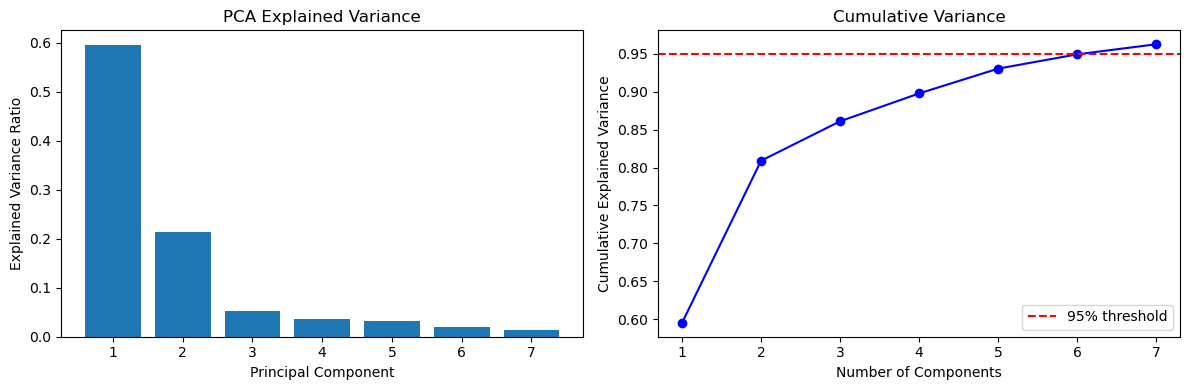

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Explained Variance')

axes[1].plot(range(1, len(pca.explained_variance_ratio_) + 1), 
             np.cumsum(pca.explained_variance_ratio_), 'bo-')
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance')
axes[1].legend()

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150)
plt.show()

In [12]:
k_range = range(2, 8)
results = {'k': [], 'kmeans_sil': [], 'gmm_sil': [],
           'kmeans_ch': [], 'gmm_ch': [], 'kmeans_db': [], 'gmm_db': [],
           'kmeans_inertia': [], 'gmm_bic': []}

for k in k_range:
    # K-Means: fit on train PCA, label all
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_train_pca)
    km_labels_all = kmeans.predict(X_all_pca)
    
    # GMM: fit on train PCA, label all
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE,
                          covariance_type='full', n_init=5)
    gmm.fit(X_train_pca)
    gmm_labels_all = gmm.predict(X_all_pca)
    
    # Metrics computed on all points with labels derived from train-fitted models
    results['k'].append(k)
    results['kmeans_sil'].append(silhouette_score(X_all_pca, km_labels_all))
    results['gmm_sil'].append(silhouette_score(X_all_pca, gmm_labels_all))
    results['kmeans_ch'].append(calinski_harabasz_score(X_all_pca, km_labels_all))
    results['gmm_ch'].append(calinski_harabasz_score(X_all_pca, gmm_labels_all))
    results['kmeans_db'].append(davies_bouldin_score(X_all_pca, km_labels_all))
    results['gmm_db'].append(davies_bouldin_score(X_all_pca, gmm_labels_all))
    results['kmeans_inertia'].append(kmeans.inertia_)
    results['gmm_bic'].append(gmm.bic(X_train_pca))         


results_df = pd.DataFrame(results)
print("Cluster Evaluation Metrics:")
print(results_df.round(4).to_string(index=False))

Cluster Evaluation Metrics:
 k  kmeans_sil  gmm_sil  kmeans_ch    gmm_ch  kmeans_db  gmm_db  kmeans_inertia    gmm_bic
 2      0.4306   0.4099  1513.3991 1176.8837     1.2131  1.3654      10394.3537 19170.0800
 3      0.1682   0.1313  1050.1909  811.1954     1.6447  1.8727       8226.3650 18783.2769
 4      0.1953   0.1490  1009.2511  681.1322     1.4832  1.9738       6653.3225 18617.4491
 5      0.1570   0.0719   858.4415  506.9296     1.5932  2.1618       5843.4092 18512.1667
 6      0.1798   0.0450  1084.2041  454.4946     1.4202  2.1019       5276.3602 18259.5962
 7      0.1407  -0.0193   868.5815  275.4676     1.5727  2.5859       4940.5795 18119.9346


In [13]:
# Use K=2 based on silhouette scores
OPTIMAL_K = 2

# Fit on train PCA
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
kmeans_final.fit(X_train_pca)

gmm_final = GaussianMixture(
    n_components=OPTIMAL_K,
    random_state=RANDOM_STATE,
    covariance_type='full',
    n_init=10
)
gmm_final.fit(X_train_pca)

# Label all dates with train fitted models
kmeans_labels_all = kmeans_final.predict(X_all_pca)
gmm_labels_all    = gmm_final.predict(X_all_pca)
gmm_probs_all     = gmm_final.predict_proba(X_all_pca)

# Create regime DataFrame on full index
df_regimes = pd.DataFrame({
    'kmeans_regime': kmeans_labels_all,
    'gmm_regime':    gmm_labels_all
}, index=df_regime_all.index)

for i in range(OPTIMAL_K):
    df_regimes[f'gmm_prob_{i}'] = gmm_probs_all[:, i]


# Regime transition features
df_regimes['regime_change'] = (df_regimes['gmm_regime'].diff() != 0).astype(float)
df_regimes['regime_change'] = df_regimes['regime_change'].fillna(0)

# Lagged regime probabilities
for lag in [1, 2, 3, 5]:
    df_regimes[f'gmm_prob_0_lag{lag}'] = df_regimes['gmm_prob_0'].shift(lag)
    df_regimes[f'gmm_prob_1_lag{lag}'] = df_regimes['gmm_prob_1'].shift(lag)

# Regime momentum
df_regimes['regime_momentum'] = df_regimes['gmm_prob_0'].diff()

# Days since last regime change
regime_changes = df_regimes['regime_change'] == 1
days_since = pd.Series(0, index=df_regimes.index)
last_change = 0
for idx_i, (idx, changed) in enumerate(regime_changes.items()):
    if changed:
        last_change = idx_i
    days_since.loc[idx] = idx_i - last_change
df_regimes['days_since_change'] = days_since

print(f"K-Means distribution (K={OPTIMAL_K}):")
print(pd.Series(kmeans_labels_all).value_counts().sort_index())
print(f"\nGMM distribution (K={OPTIMAL_K}):")
print(pd.Series(gmm_labels_all).value_counts().sort_index())
print(f"\nRegime changes detected: {df_regimes['regime_change'].sum():.0f}")
print(f"K-Means Silhouette: {silhouette_score(X_all_pca, kmeans_labels_all):.4f}")
print(f"GMM Silhouette: {silhouette_score(X_all_pca, gmm_labels_all):.4f}")

K-Means distribution (K=2):
0     709
1    3044
dtype: int64

GMM distribution (K=2):
0     643
1    3110
dtype: int64

Regime changes detected: 119
K-Means Silhouette: 0.4306
GMM Silhouette: 0.4099


In [14]:
# View cluster characteristics for K=2
df_analysis = df_regime_features.copy()
df_analysis['kmeans_regime'] = df_regimes['kmeans_regime']
df_analysis['gmm_regime'] = df_regimes['gmm_regime']

print("K-Means Regime Characteristics")
kmeans_chars = df_analysis.groupby('kmeans_regime')[['avg_vol', 'market_mom', 'dispersion', 'rolling_corr']].mean()
print(kmeans_chars.round(6))

print("GMM Regime Characteristics")
gmm_chars = df_analysis.groupby('gmm_regime')[['avg_vol', 'market_mom', 'dispersion', 'rolling_corr']].mean()
print(gmm_chars.round(6))

K-Means Regime Characteristics
                avg_vol  market_mom  dispersion  rolling_corr
kmeans_regime                                                
0              0.019393   -0.001398    0.009509      0.735940
1              0.009089    0.000784    0.005880      0.450976
GMM Regime Characteristics
             avg_vol  market_mom  dispersion  rolling_corr
gmm_regime                                                
0           0.019483   -0.000670    0.009450      0.797016
1           0.009289    0.000587    0.005969      0.444396


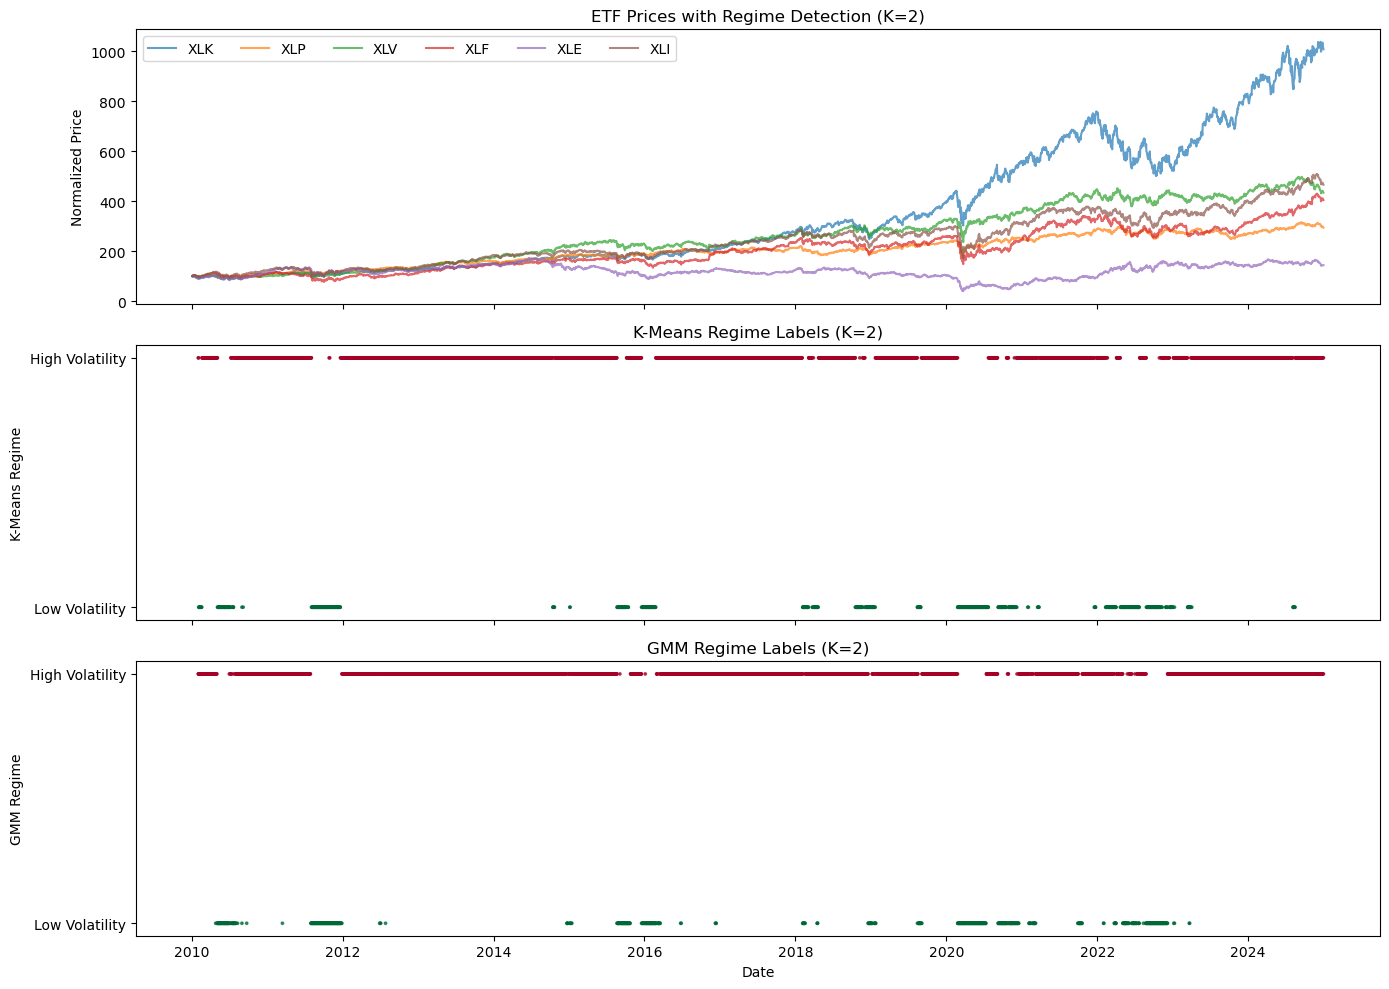


Key regime transitions:
- 2020 COVID: Transition to high volatility regime
- 2022 Rate hikes: Extended high volatility period
- 2023-2024: Return to low volatility regime


In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Prices with regime overlay
for ticker in tickers:
    normalized = df_close[ticker] / df_close[ticker].iloc[0] * 100
    axes[0].plot(df_close.index, normalized, alpha=0.7, label=ticker)
axes[0].set_ylabel('Normalized Price')
axes[0].set_title('ETF Prices with Regime Detection (K=2)')
axes[0].legend(loc='upper left', ncol=6)

# K-Means regimes
scatter1 = axes[1].scatter(df_regimes.index, df_regimes['kmeans_regime'], 
                           c=df_regimes['kmeans_regime'], cmap='RdYlGn_r', s=3, alpha=0.7)
axes[1].set_ylabel('K-Means Regime')
axes[1].set_title('K-Means Regime Labels (K=2)')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Low Volatility', 'High Volatility'])

# GMM regimes
scatter2 = axes[2].scatter(df_regimes.index, df_regimes['gmm_regime'], 
                           c=df_regimes['gmm_regime'], cmap='RdYlGn_r', s=3, alpha=0.7)
axes[2].set_ylabel('GMM Regime')
axes[2].set_title('GMM Regime Labels (K=2)')
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['Low Volatility', 'High Volatility'])
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig('regime_timeline.png', dpi=150)
plt.show()

print("\nKey regime transitions:")
print("- 2020 COVID: Transition to high volatility regime")
print("- 2022 Rate hikes: Extended high volatility period")
print("- 2023-2024: Return to low volatility regime")

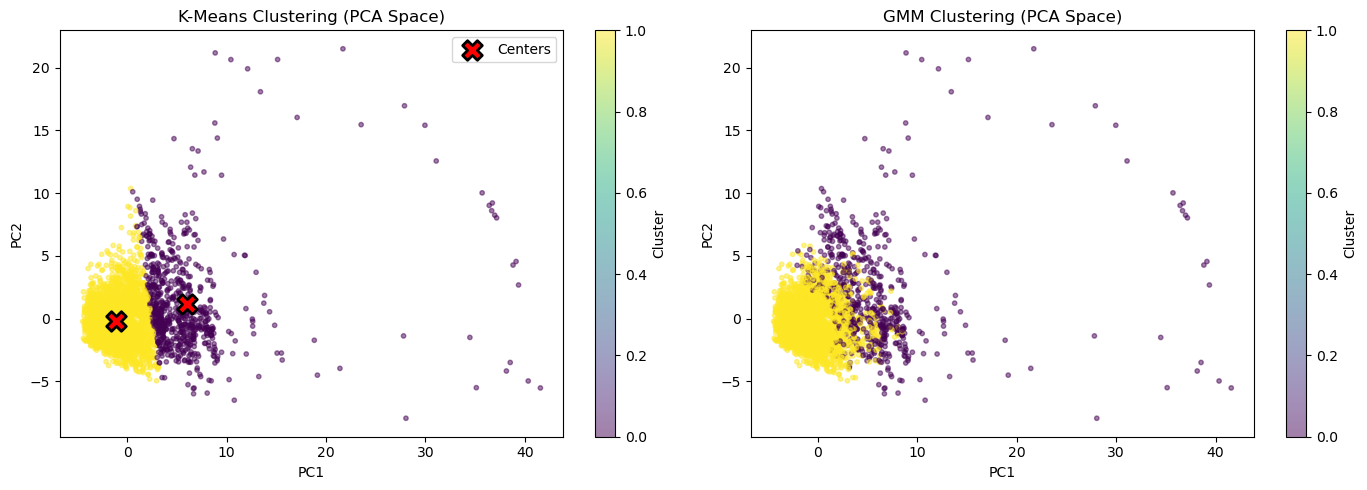

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means in PCA space
scatter1 = axes[0].scatter(X_all_pca[:, 0], X_all_pca[:, 1], c=kmeans_labels_all, cmap='viridis', alpha=0.5, s=10)
axes[0].scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
                c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Centers')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('K-Means Clustering (PCA Space)')
axes[0].legend()
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# GMM in PCA space
scatter2 = axes[1].scatter(X_all_pca[:, 0], X_all_pca[:, 1], c=gmm_labels_all, cmap='viridis', alpha=0.5, s=10)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('GMM Clustering (PCA Space)')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

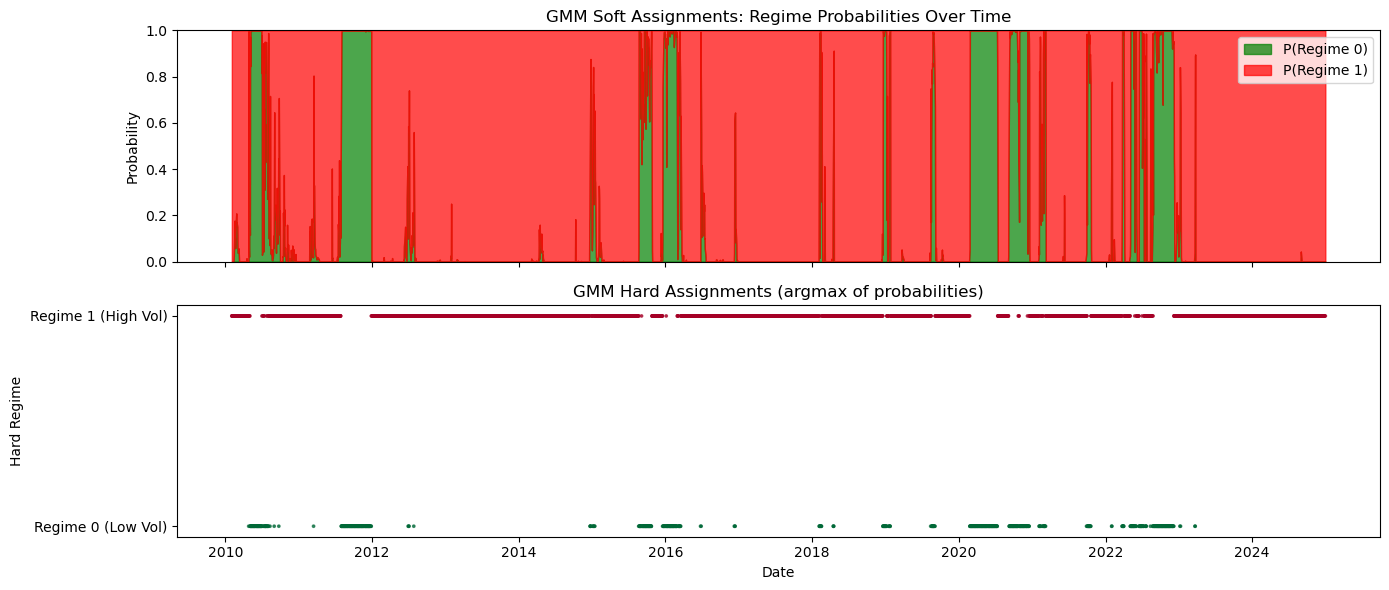

In [17]:
# GMM probability visualization (advantage over K-Means: soft assignments)
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Probability of Regime 0 over time
axes[0].fill_between(df_regimes.index, 0, df_regimes['gmm_prob_0'], alpha=0.7, label='P(Regime 0)', color='green')
axes[0].fill_between(df_regimes.index, df_regimes['gmm_prob_0'], 1, alpha=0.7, label='P(Regime 1)', color='red')
axes[0].set_ylabel('Probability')
axes[0].set_title('GMM Soft Assignments: Regime Probabilities Over Time')
axes[0].legend(loc='upper right')
axes[0].set_ylim(0, 1)

# Hard assignments for comparison
axes[1].scatter(df_regimes.index, df_regimes['gmm_regime'], c=df_regimes['gmm_regime'], 
                cmap='RdYlGn_r', s=3, alpha=0.7)
axes[1].set_ylabel('Hard Regime')
axes[1].set_xlabel('Date')
axes[1].set_title('GMM Hard Assignments (argmax of probabilities)')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Regime 0 (Low Vol)', 'Regime 1 (High Vol)'])

plt.tight_layout()
plt.show()

## 3. Integration With Prediction & Regime-Informed Experiments

In [18]:
class StudentBaseline:
    
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.lasso_weight = 0.8
        self.fitted_ = False
        self.pipe_lasso = None
        self.pipe_xgb = None
        self.n_lags = 10
        self.mom_windows = (10, 30)
        self.vol_window = 30
        self.sma_windows = (10, 30)
        self.ema_windows = (10, 30)
        self.rsi_window = 14

    def _log_returns(self, series):
        return np.log(series / series.shift(1)).replace([np.inf, -np.inf], 0.0)

    def _rsi_ewm(self, series, window):
        diff = series.diff()
        gain = diff.clip(lower=0.0)
        loss = -diff.clip(upper=0.0)
        avg_gain = gain.ewm(alpha=1/window, adjust=False, min_periods=window).mean()
        avg_loss = loss.ewm(alpha=1/window, adjust=False, min_periods=window).mean()
        rs = avg_gain / avg_loss.replace(0, np.nan)
        return (1 - (1 / (1 + rs))).fillna(0.5)

    def _make_features(self, X):
        close = X['Close'] if 'Close' in X.columns else X['close']
        high = X['High'] if 'High' in X.columns else X['high']
        low = X['Low'] if 'Low' in X.columns else X['low']
        volume = X['Volume'] if 'Volume' in X.columns else X['volume']
        
        lr = self._log_returns(close)
        feats = {}
        
        for i in range(1, self.n_lags + 1):
            feats[f'lag{i}'] = lr.shift(i)
        for w in self.mom_windows:
            feats[f'mom_{w}'] = lr.rolling(w, min_periods=w).mean()
        feats[f'vol_{self.vol_window}'] = lr.rolling(self.vol_window, min_periods=self.vol_window).std()
        for w in self.sma_windows:
            sma = close.rolling(w, min_periods=w).mean()
            feats[f'sma_dist_{w}'] = (close - sma) / sma.replace(0, np.nan)
        for w in self.ema_windows:
            ema = close.ewm(span=w, adjust=False, min_periods=w).mean()
            feats[f'ema_dist_{w}'] = (close - ema) / ema.replace(0, np.nan)
        feats[f'rsi_{self.rsi_window}'] = self._rsi_ewm(close, self.rsi_window)
        vol_sma = volume.rolling(self.vol_window, min_periods=self.vol_window).mean()
        feats['vol_rel'] = volume / vol_sma.replace(0, np.nan)
        feats['day_range'] = (high - low) / close.replace(0, np.nan)
        
        F = pd.DataFrame(feats, index=X.index)
        return F.replace([np.inf, -np.inf], 0.0).fillna(0.0)

    def fit(self, X_train, y_train, meta=None):
        F = self._make_features(X_train).shift(1)
        y, F = y_train.align(F, join='inner', axis=0)
        F = F.dropna()
        y = y.loc[F.index]
        
        if len(F) < 50:
            self.fitted_ = False
            return self
        
        self.pipe_lasso = Pipeline([('scaler', StandardScaler()), 
                                    ('model', Lasso(alpha=0.1, random_state=self.random_state, max_iter=10000))])
        self.pipe_lasso.fit(F.values, y.values)
        
        self.pipe_xgb = Pipeline([('scaler', StandardScaler()), 
                                  ('model', XGBRegressor(n_estimators=100, max_depth=3, 
                                                         random_state=self.random_state, n_jobs=-1, verbosity=0))])
        self.pipe_xgb.fit(F.values, y.values)
        self.fitted_ = True
        return self

    def predict(self, X, meta=None):
        F = self._make_features(X).fillna(0.0)
        if not self.fitted_:
            return pd.Series(0.0, index=F.index, name='y_pred')
        y_lasso = self.pipe_lasso.predict(F.values)
        y_xgb = self.pipe_xgb.predict(F.values)
        y_pred = self.lasso_weight * y_lasso + (1 - self.lasso_weight) * y_xgb
        return pd.Series(y_pred, index=F.index, name='y_pred')

print("StudentBaseline defined")

StudentBaseline defined


In [19]:
class StudentExt:
    
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.lasso_weight = 0.8
        self.fitted_ = False
        self.pipe_lasso = None
        self.pipe_xgb = None
        self.n_lags = 10
        self.mom_windows = (10, 30)
        self.vol_window = 30
        self.sma_windows = (10, 30)
        self.ema_windows = (10, 30)
        self.rsi_window = 14
        self.feature_names = None

    def _log_returns(self, series):
        return np.log(series / series.shift(1)).replace([np.inf, -np.inf], 0.0)

    def _one_hot_regime(self, regime_df):
        # Take hard GMM label and one hot it and lag by 1
        labels = regime_df['gmm_regime'].shift(1)
        oh = pd.get_dummies(labels, prefix='reg', dummy_na=False)
        return oh


    def _rsi_ewm(self, series, window):
        diff = series.diff()
        gain = diff.clip(lower=0.0)
        loss = -diff.clip(upper=0.0)
        avg_gain = gain.ewm(alpha=1/window, adjust=False, min_periods=window).mean()
        avg_loss = loss.ewm(alpha=1/window, adjust=False, min_periods=window).mean()
        rs = avg_gain / avg_loss.replace(0, np.nan)
        return (1 - (1 / (1 + rs))).fillna(0.5)

    def _make_base_features(self, X):
        close = X['Close'] if 'Close' in X.columns else X['close']
        high = X['High'] if 'High' in X.columns else X['high']
        low = X['Low'] if 'Low' in X.columns else X['low']
        volume = X['Volume'] if 'Volume' in X.columns else X['volume']
        
        lr = self._log_returns(close)
        feats = {}
        
        for i in range(1, self.n_lags + 1):
            feats[f'lag{i}'] = lr.shift(i)
        for w in self.mom_windows:
            feats[f'mom_{w}'] = lr.rolling(w, min_periods=w).mean()
        feats[f'vol_{self.vol_window}'] = lr.rolling(self.vol_window, min_periods=self.vol_window).std()
        for w in self.sma_windows:
            sma = close.rolling(w, min_periods=w).mean()
            feats[f'sma_dist_{w}'] = (close - sma) / sma.replace(0, np.nan)
        for w in self.ema_windows:
            ema = close.ewm(span=w, adjust=False, min_periods=w).mean()
            feats[f'ema_dist_{w}'] = (close - ema) / ema.replace(0, np.nan)
        feats[f'rsi_{self.rsi_window}'] = self._rsi_ewm(close, self.rsi_window)
        vol_sma = volume.rolling(self.vol_window, min_periods=self.vol_window).mean()
        feats['vol_rel'] = volume / vol_sma.replace(0, np.nan)
        feats['day_range'] = (high - low) / close.replace(0, np.nan)
        
        F = pd.DataFrame(feats, index=X.index)
        return F.replace([np.inf, -np.inf], 0.0).fillna(0.0)

    def _add_regime_features(self, F_base, regime_df):
        # Select lagged probabilities & transition/momentum
        regime_cols = [
            c for c in regime_df.columns
            if (
                c.startswith('gmm_prob_') and 'lag' in c
            ) or c in ['regime_change', 'regime_momentum', 'days_since_change']
        ]
        
        # Align regime features to feature index
        regime_aligned = regime_df[regime_cols].reindex(F_base.index)
        
        # One hot of lagged hard regime labels
        reg_oh = self._one_hot_regime(regime_df).reindex(F_base.index)
        
        # Base + regime + one hot
        F_combined = F_base.join(regime_aligned, how='left').join(reg_oh, how='left')
        
        # Interaction features: regime × key base features
        key_feats = [c for c in F_base.columns if c in ['lag1', f'vol_{self.vol_window}']]
        for rf in reg_oh.columns:
            for bf in key_feats:
                F_combined[f'{bf}_x_{rf}'] = F_base[bf] * reg_oh[rf]
        
        return F_combined


    def fit(self, X_train, y_train, meta=None):
        F_base = self._make_base_features(X_train).shift(1)
        
        if meta is not None and 'df_regimes' in meta:
            F_combined = self._add_regime_features(F_base, meta['df_regimes'])
        else:
            F_combined = F_base
        
        y, F = y_train.align(F_combined, join='inner', axis=0)
        F = F.dropna()
        y = y.loc[F.index]
        
        if len(F) < 50:
            self.fitted_ = False
            return self
        
        self.pipe_lasso = Pipeline([
            ('scaler', StandardScaler()),
            ('model', Lasso(alpha=0.1, random_state=self.random_state, max_iter=10000))
        ])
        self.pipe_lasso.fit(F.values, y.values)
        
        self.pipe_xgb = Pipeline([
            ('scaler', StandardScaler()),
            ('model', XGBRegressor(n_estimators=100, max_depth=3,
                                   random_state=self.random_state, n_jobs=-1, verbosity=0))
        ])
        self.pipe_xgb.fit(F.values, y.values)
        
        self.feature_names = F.columns.tolist()
        self.fitted_ = True
        return self

    def predict(self, X, meta=None):
        F_base = self._make_base_features(X)
        
        if not self.fitted_:
            return pd.Series(0.0, index=F_base.index, name='y_pred')
        
        if meta is not None and 'df_regimes' in meta:
            F_combined = self._add_regime_features(F_base, meta['df_regimes'])
        else:
            F_combined = F_base
        
        for col in self.feature_names:
            if col not in F_combined.columns:
                F_combined[col] = 0.0
        F_combined = F_combined[self.feature_names].fillna(0.0)
        
        y_lasso = self.pipe_lasso.predict(F_combined.values)
        y_xgb = self.pipe_xgb.predict(F_combined.values)
        y_pred = self.lasso_weight * y_lasso + (1 - self.lasso_weight) * y_xgb
        
        return pd.Series(y_pred, index=F_combined.index, name='y_pred')

print("StudentExt defined with k=2 and features")

StudentExt defined with k=2 and features


In [20]:
# Forward log return
def compute_target(close, H=1):
    y = np.log(close.shift(-H) / close)
    return y.replace([np.inf, -np.inf], 0.0).rename('y_true')
    
# Compute diracc, rmse
def compute_metrics(y_true, y_pred):
    df = pd.concat([y_true.rename('y'), y_pred.rename('yhat')], axis=1).dropna()
    if df.empty:
        return {'dir_acc': np.nan, 'mae': np.nan, 'rmse': np.nan}
    dir_acc = (np.sign(df['y']) == np.sign(df['yhat'])).mean()
    mae = np.abs(df['y'] - df['yhat']).mean()
    rmse = np.sqrt(((df['y'] - df['yhat']) ** 2).mean())
    return {'dir_acc': dir_acc, 'mae': mae, 'rmse': rmse}

# Walk forward with regime features
def run_walk_forward(model_class, ticker_data, H=1, min_train=252*4, step=10, meta=None, **kwargs):
    close_col = 'Close' if 'Close' in ticker_data.columns else 'close'
    y_full = compute_target(ticker_data[close_col], H=H).dropna()
    X_full, y_full = ticker_data.align(y_full, join='inner', axis=0)
    
    if len(X_full) < min_train:
        return None, None
    
    preds, trues = [], []
    for i_start in range(min_train, len(X_full), step):
        i_end = min(i_start + step, len(X_full))
        X_train, y_train = X_full.iloc[:i_start], y_full.iloc[:i_start]
        X_test, y_test = X_full.iloc[i_start:i_end], y_full.iloc[i_start:i_end]
        
        # For regime models, filter meta to only include training period data
        meta_train = None
        if meta is not None and 'df_regimes' in meta:
            # Only use regime labels up to training cutoff (avoids look ahead)
            train_end_date = X_train.index[-1]
            regime_train = meta['df_regimes'].loc[:train_end_date]
            meta_train = {'df_regimes': regime_train}
        
        model = model_class(**kwargs)
        model.fit(X_train, y_train, meta=meta_train)
        
        # Use regime labels up to test period for prediction
        meta_test = None
        if meta is not None and 'df_regimes' in meta:
            test_end_date = X_test.index[-1]
            regime_test = meta['df_regimes'].loc[:test_end_date]
            meta_test = {'df_regimes': regime_test}
        
        y_pred = model.predict(X_test, meta=meta_test)
        
        preds.append(y_pred)
        trues.append(y_test)
    
    y_pred_all = pd.concat(preds)
    y_true_all = pd.concat(trues)
    y_true_all, y_pred_all = y_true_all.align(y_pred_all, join='inner', axis=0)
    return y_true_all, y_pred_all

print("Evaluation functions defined")

Evaluation functions defined


In [21]:
results_improved = []

print("Running GMM walk forward evaluation")

for ticker in tickers:
    print(f"\nProcessing {ticker}")
    
    ticker_data = df_raw[df_raw['ticker'] == ticker].set_index('date').sort_index()
    ticker_data.columns = [c.capitalize() for c in ticker_data.columns]
    
    t0 = time.time()
    y_true, y_pred = run_walk_forward(
        StudentExt, ticker_data, H=1,
        random_state=RANDOM_STATE,
        meta={'df_regimes': df_regimes}
    )
    t_elapsed = time.time() - t0
    
    if y_true is not None:
        m = compute_metrics(y_true, y_pred)
        m['ticker'] = ticker
        m['time'] = t_elapsed
        results_improved.append(m)
        print(f"  Improved: DirAcc={m['dir_acc']:.4f}, RMSE={m['rmse']:.6f}")

Running GMM walk forward evaluation

Processing XLK
  Improved: DirAcc=0.5391, RMSE=0.014241

Processing XLP
  Improved: DirAcc=0.5217, RMSE=0.009047

Processing XLV
  Improved: DirAcc=0.5203, RMSE=0.010473

Processing XLF
  Improved: DirAcc=0.5134, RMSE=0.013614

Processing XLE
  Improved: DirAcc=0.4866, RMSE=0.018477

Processing XLI
  Improved: DirAcc=0.5105, RMSE=0.012183


In [22]:
# Baseline walk forward evaluation
results_baseline = []

print("Running baseline walk forward evaluation")

for ticker in tickers:
    print(f"\nProcessing {ticker} (Baseline)")
    
    ticker_data = df_raw[df_raw['ticker'] == ticker].set_index('date').sort_index()
    ticker_data.columns = [c.capitalize() for c in ticker_data.columns]
    
    t0 = time.time()
    y_true_base, y_pred_base = run_walk_forward(
        StudentBaseline,
        ticker_data,
        H=1,
        random_state=RANDOM_STATE,
        meta=None # No regimes for baseline
    )
    t_base = time.time() - t0
    
    if y_true_base is not None:
        m = compute_metrics(y_true_base, y_pred_base)
        m['ticker'] = ticker
        m['time'] = t_base
        results_baseline.append(m)
        print(f"  Baseline: DirAcc={m['dir_acc']:.4f}, RMSE={m['rmse']:.6f}, Time={t_base:.1f}s")

Running baseline walk forward evaluation

Processing XLK (Baseline)
  Baseline: DirAcc=0.5134, RMSE=0.014267, Time=40.7s

Processing XLP (Baseline)
  Baseline: DirAcc=0.5199, RMSE=0.009051, Time=39.2s

Processing XLV (Baseline)
  Baseline: DirAcc=0.5242, RMSE=0.010478, Time=41.1s

Processing XLF (Baseline)
  Baseline: DirAcc=0.5130, RMSE=0.013588, Time=39.9s

Processing XLE (Baseline)
  Baseline: DirAcc=0.4870, RMSE=0.018434, Time=41.7s

Processing XLI (Baseline)
  Baseline: DirAcc=0.5134, RMSE=0.012180, Time=42.9s


In [23]:
# Baseline vs StudentExt: DirAcc and RMSE per ticker + average

# Baseline metrics per ticker
df_base = pd.DataFrame(results_baseline)[['ticker', 'dir_acc', 'rmse']].rename(
    columns={'dir_acc': 'dir_acc_base', 'rmse':    'rmse_base'}
)

# Improved regime model metrics per ticker
df_imp = pd.DataFrame(results_improved)[['ticker', 'dir_acc', 'rmse']].rename(
    columns={'dir_acc': 'dir_acc_regime', 'rmse':    'rmse_regime'}
)

# Merge on ticker
df_comp = df_base.merge(df_imp, on='ticker')

# Add mean row at bottom
mean_row = pd.DataFrame({
    'ticker':        ['MEAN'],
    'dir_acc_base':  [df_comp['dir_acc_base'].mean()],
    'rmse_base':     [df_comp['rmse_base'].mean()],
    'dir_acc_regime':[df_comp['dir_acc_regime'].mean()],
    'rmse_regime':   [df_comp['rmse_regime'].mean()]
})

df_out = pd.concat([df_comp, mean_row], ignore_index=True)

print("\nBASELINE vs StudentExt (DirAcc, RMSE):")
display(df_out[['ticker',
                'dir_acc_base',  'rmse_base',
                'dir_acc_regime','rmse_regime']].round(4))



BASELINE vs StudentExt (DirAcc, RMSE):


,ticker,dir_acc_base,rmse_base,dir_acc_regime,rmse_regime
0,XLK,0.5134,0.0143,0.5391,0.0142
1,XLP,0.5199,0.0091,0.5217,0.0090
2,XLV,0.5242,0.0105,0.5203,0.0105
3,XLF,0.5130,0.0136,0.5134,0.0136
4,XLE,0.4870,0.0184,0.4866,0.0185
5,XLI,0.5134,0.0122,0.5105,0.0122
6,MEAN,0.5118,0.0130,0.5153,0.0130


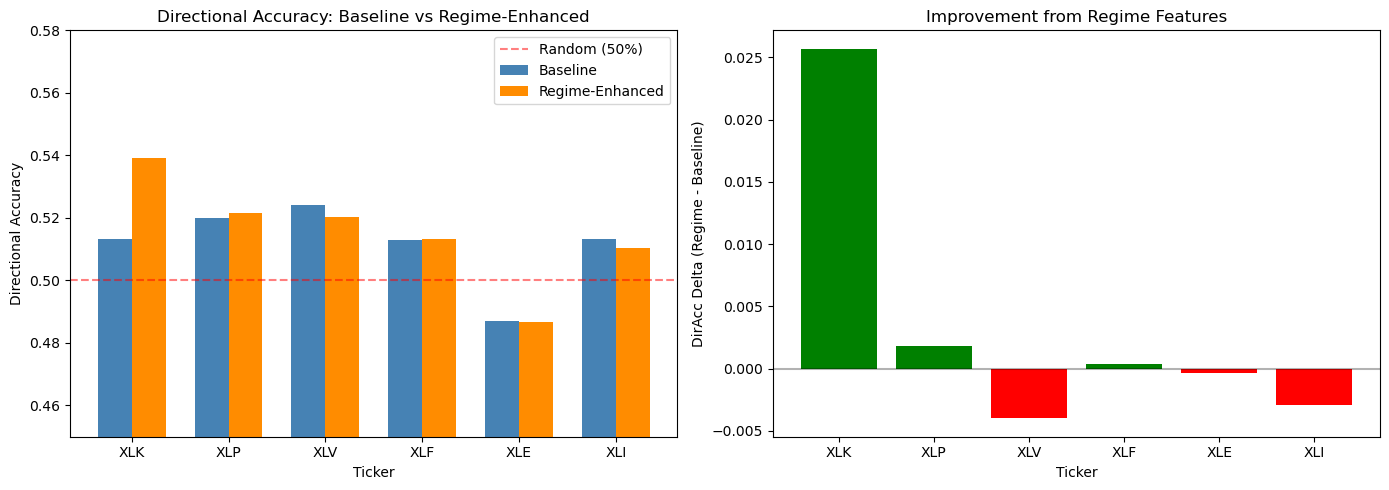

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df_comp[df_comp['ticker'] != 'MEAN'] if 'MEAN' in df_comp['ticker'].values else df_comp

x = np.arange(len(df_plot))
width = 0.35

# DirAcc comparison
axes[0].bar(x - width/2, df_plot['dir_acc_base'],   width, label='Baseline',        color='steelblue')
axes[0].bar(x + width/2, df_plot['dir_acc_regime'], width, label='Regime-Enhanced', color='darkorange')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random (50%)')
axes[0].set_xlabel('Ticker')
axes[0].set_ylabel('Directional Accuracy')
axes[0].set_title('Directional Accuracy: Baseline vs Regime-Enhanced')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_plot['ticker'])
axes[0].legend()
axes[0].set_ylim(0.45, 0.58)

# Delta plot
dir_acc_delta = df_plot['dir_acc_regime'] - df_plot['dir_acc_base']
colors = ['green' if d > 0 else 'red' for d in dir_acc_delta]

axes[1].bar(x, dir_acc_delta, color=colors)
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1].set_xlabel('Ticker')
axes[1].set_ylabel('DirAcc Delta (Regime - Baseline)')
axes[1].set_title('Improvement from Regime Features')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_plot['ticker'])

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()


In [25]:
# View performance for one ticker
ticker = 'XLK'
ticker_data = df_raw[df_raw['ticker'] == ticker].set_index('date').sort_index()
ticker_data.columns = [c.capitalize() for c in ticker_data.columns]

y_true, y_pred = run_walk_forward(
    StudentExt,
    ticker_data,
    H=1,
    random_state=RANDOM_STATE,
    meta={'df_regimes': df_regimes}
)

# Align with GMM regimes
regime_aligned = df_regimes['gmm_regime'].reindex(y_true.index)

df_perf = pd.DataFrame({
    'y_true': y_true,
    'y_pred': y_pred,
    'regime': regime_aligned,
    'correct': np.sign(y_true) == np.sign(y_pred)
}).dropna()

print(f"Performance by Regime for {ticker}:")
for regime in sorted(df_perf['regime'].unique()):
    r_data = df_perf[df_perf['regime'] == regime]
    if len(r_data) > 0:
        d_acc = r_data['correct'].mean()
        rmse = np.sqrt(((r_data['y_true'] - r_data['y_pred'])**2).mean())
        regime_name = "Low Volatility" if regime == 0 else "High Volatility"
        print(f"Regime {int(regime)} ({regime_name}): DirAcc={d_acc:.4f}, RMSE={rmse:.6f}, N={len(r_data)}")

Performance by Regime for XLK:
Regime 0 (Low Volatility): DirAcc=0.5106, RMSE=0.022323, N=472
Regime 1 (High Volatility): DirAcc=0.5449, RMSE=0.011914, N=2292


## 4. Baseline Comparison vs Published Method

In [26]:
def greedy_gaussian_segmentation(X, k_max=5, lamb=1e-1):
    T, n = X.shape
    breakpoints = [0, T]

    #Compute regularised Gaussian log likelihood of segment
    def segment_likelihood(X_seg, lamb):
        T_seg, n = X_seg.shape
        if T_seg < n + 1:
            return -np.inf
        mu = np.mean(X_seg, axis=0)
        centered = X_seg - mu
        S = (centered.T @ centered) / T_seg
        S_reg = S + lamb * np.eye(n)
        try:
            sign, logdet = np.linalg.slogdet(S_reg)
            if sign <= 0:
                return -np.inf
            ll = -0.5 * T_seg * (n * np.log(2 * np.pi) + logdet + n)
        except:
            return -np.inf
        return ll
        
    # Compute total log likelihood across all segments
    def total_likelihood(X, breakpoints, lamb):
        ll = 0
        for i in range(len(breakpoints) - 1):
            start, end = breakpoints[i], breakpoints[i + 1]
            ll += segment_likelihood(X[start:end], lamb)
        return ll
    
    # Greedy search for breakpoints
    for k in range(k_max):
        best_bp = None
        best_ll = total_likelihood(X, breakpoints, lamb)
        
        for i in range(len(breakpoints) - 1):
            start, end = breakpoints[i], breakpoints[i + 1]
            # Search within segment
            min_seg = max(n + 1, 20)
            for bp in range(start + min_seg, end - min_seg, 10):  # Step by 10 for speed
                new_breakpoints = sorted(breakpoints + [bp])
                new_ll = total_likelihood(X, new_breakpoints, lamb)
                if new_ll > best_ll:
                    best_ll = new_ll
                    best_bp = bp
        
        if best_bp is None:
            break
        breakpoints = sorted(breakpoints + [best_bp])
    
    # Create segment labels
    segment_labels = np.zeros(T, dtype=int)
    for i in range(len(breakpoints) - 1):
        start, end = breakpoints[i], breakpoints[i + 1]
        segment_labels[start:end] = i
    
    return breakpoints, segment_labels


def build_ggs_regimes(df_regime_features, k_max=3, lamb=0.1):
    
    # Select key features
    ggs_cols = [c for c in df_regime_features.columns 
                if any(x in c for x in ['avg_vol', 'market_mom', 'dispersion', 'rolling_corr'])]
    df_ggs_input = df_regime_features[ggs_cols].dropna()
    
    X = df_ggs_input.values
    dates = df_ggs_input.index
    
    # Standardize
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0) + 1e-8
    X_scaled = (X - X_mean) / X_std
    
    # Run GGS
    breakpoints, segment_labels = greedy_gaussian_segmentation(X_scaled, k_max=k_max, lamb=lamb)
    
    # Create regime DataFrame
    n_segments = len(breakpoints) - 1
    df_regimes_ggs = pd.DataFrame(index=dates)
    df_regimes_ggs['ggs_regime'] = segment_labels
    
    # One-hot encode segments
    for i in range(n_segments):
        df_regimes_ggs[f'ggs_seg_{i}'] = (segment_labels == i).astype(float)
    
    print(f"Hallac GGS found {n_segments} segments:")
    for i in range(n_segments):
        count = (segment_labels == i).sum()
        start_idx, end_idx = breakpoints[i], breakpoints[i+1] - 1
        print(f"  Segment {i}: {dates[start_idx].date()} to {dates[end_idx].date()} ({count} days)")
    
    return df_regimes_ggs, breakpoints

print("GGS functions defined.")

GGS functions defined.


In [27]:
# Build GGS regimes
print("Running Hallac et al. (2019) GGS")
df_regimes_ggs, ggs_breakpoints = build_ggs_regimes(df_regime_features, k_max=3, lamb=0.1)

Running Hallac et al. (2019) GGS
Hallac GGS found 4 segments:
  Segment 0: 2010-02-02 to 2016-04-13 (1560 days)
  Segment 1: 2016-04-14 to 2020-03-05 (980 days)
  Segment 2: 2020-03-06 to 2020-07-14 (90 days)
  Segment 3: 2020-07-15 to 2024-12-30 (1123 days)


In [28]:
# Hallac GGS based Model
class StudentGGS:
    
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.lasso_weight = 0.8
        self.fitted_ = False
        self.pipe_lasso = None
        self.pipe_xgb = None
        self.n_lags = 10
        self.mom_windows = (10, 30)
        self.vol_window = 30
        self.sma_windows = (10, 30)
        self.ema_windows = (10, 30)
        self.rsi_window = 14
        self.feature_names = None

    def _log_returns(self, series):
        return np.log(series / series.shift(1)).replace([np.inf, -np.inf], 0.0)

    def _rsi_ewm(self, series, window):
        diff = series.diff()
        gain = diff.clip(lower=0.0)
        loss = -diff.clip(upper=0.0)
        avg_gain = gain.ewm(alpha=1/window, adjust=False, min_periods=window).mean()
        avg_loss = loss.ewm(alpha=1/window, adjust=False, min_periods=window).mean()
        rs = avg_gain / avg_loss.replace(0, np.nan)
        return (1 - (1 / (1 + rs))).fillna(0.5)

    def _make_base_features(self, X):
        close = X['Close'] if 'Close' in X.columns else X['close']
        high = X['High'] if 'High' in X.columns else X['high']
        low = X['Low'] if 'Low' in X.columns else X['low']
        volume = X['Volume'] if 'Volume' in X.columns else X['volume']
        
        lr = self._log_returns(close)
        feats = {}
        
        for i in range(1, self.n_lags + 1):
            feats[f'lag{i}'] = lr.shift(i)
        for w in self.mom_windows:
            feats[f'mom_{w}'] = lr.rolling(w, min_periods=w).mean()
        feats[f'vol_{self.vol_window}'] = lr.rolling(self.vol_window, min_periods=self.vol_window).std()
        for w in self.sma_windows:
            sma = close.rolling(w, min_periods=w).mean()
            feats[f'sma_dist_{w}'] = (close - sma) / sma.replace(0, np.nan)
        for w in self.ema_windows:
            ema = close.ewm(span=w, adjust=False, min_periods=w).mean()
            feats[f'ema_dist_{w}'] = (close - ema) / ema.replace(0, np.nan)
        feats[f'rsi_{self.rsi_window}'] = self._rsi_ewm(close, self.rsi_window)
        vol_sma = volume.rolling(self.vol_window, min_periods=self.vol_window).mean()
        feats['vol_rel'] = volume / vol_sma.replace(0, np.nan)
        feats['day_range'] = (high - low) / close.replace(0, np.nan)
        
        F = pd.DataFrame(feats, index=X.index)
        return F.replace([np.inf, -np.inf], 0.0).fillna(0.0)

    def _add_regime_features(self, F_base, regime_df):
        seg_cols = [c for c in regime_df.columns if 'ggs_seg' in c]
        regime_aligned = regime_df[seg_cols].reindex(F_base.index)
        F_combined = F_base.join(regime_aligned, how='left')
        
        # Interaction features
        if f'vol_{self.vol_window}' in F_base.columns:
            vol_col = F_base[f'vol_{self.vol_window}']
            for sc in seg_cols:
                F_combined[f'{sc}_x_vol'] = regime_aligned[sc] * vol_col
        
        return F_combined

    def fit(self, X_train, y_train, meta=None):
        F_base = self._make_base_features(X_train).shift(1)
        
        if meta is not None and 'df_regimes' in meta:
            F_combined = self._add_regime_features(F_base, meta['df_regimes'])
        else:
            F_combined = F_base
        
        y, F = y_train.align(F_combined, join='inner', axis=0)
        F = F.dropna()
        y = y.loc[F.index]
        
        if len(F) < 50:
            self.fitted_ = False
            return self
        
        self.pipe_lasso = Pipeline([
            ('scaler', StandardScaler()),
            ('model', Lasso(alpha=0.1, random_state=self.random_state, max_iter=10000))
        ])
        self.pipe_lasso.fit(F.values, y.values)
        
        self.pipe_xgb = Pipeline([
            ('scaler', StandardScaler()),
            ('model', XGBRegressor(n_estimators=100, max_depth=3,
                                   random_state=self.random_state, n_jobs=-1, verbosity=0))
        ])
        self.pipe_xgb.fit(F.values, y.values)
        
        self.feature_names = F.columns.tolist()
        self.fitted_ = True
        return self

    def predict(self, X, meta=None):
        F_base = self._make_base_features(X)
        
        if not self.fitted_:
            return pd.Series(0.0, index=F_base.index, name='y_pred')
        
        if meta is not None and 'df_regimes' in meta:
            F_combined = self._add_regime_features(F_base, meta['df_regimes'])
        else:
            F_combined = F_base
        
        for col in self.feature_names:
            if col not in F_combined.columns:
                F_combined[col] = 0.0
        F_combined = F_combined[self.feature_names].fillna(0.0)
        
        y_lasso = self.pipe_lasso.predict(F_combined.values)
        y_xgb = self.pipe_xgb.predict(F_combined.values)
        y_pred = self.lasso_weight * y_lasso + (1 - self.lasso_weight) * y_xgb
        
        return pd.Series(y_pred, index=F_combined.index, name='y_pred')

print("StudentGGS defined.")

StudentGGS defined.


In [29]:
results_ggs = []

print("Running Hallac GGS walk-forward evaluation...")

for ticker in tickers:
    print(f"\nProcessing {ticker} (GGS)")
    
    ticker_data = df_raw[df_raw['ticker'] == ticker].set_index('date').sort_index()
    ticker_data.columns = [c.capitalize() for c in ticker_data.columns]
    
    t0 = time.time()
    y_true_ggs, y_pred_ggs = run_walk_forward(
        StudentGGS, ticker_data, H=1,
        random_state=RANDOM_STATE,
        meta={'df_regimes': df_regimes_ggs}
    )
    t_ggs = time.time() - t0
    
    if y_true_ggs is not None:
        m = compute_metrics(y_true_ggs, y_pred_ggs)
        m['ticker'] = ticker
        m['time'] = t_ggs
        results_ggs.append(m)
        print(f"  GGS: DirAcc={m['dir_acc']:.4f}, RMSE={m['rmse']:.6f}, Time={t_ggs:.1f}s")

print("\n" + "=" * 60)

Running Hallac GGS walk-forward evaluation...

Processing XLK (GGS)
  GGS: DirAcc=0.5478, RMSE=0.014283, Time=55.3s

Processing XLP (GGS)
  GGS: DirAcc=0.5174, RMSE=0.009037, Time=54.0s

Processing XLV (GGS)
  GGS: DirAcc=0.4931, RMSE=0.010496, Time=57.6s

Processing XLF (GGS)
  GGS: DirAcc=0.5098, RMSE=0.013598, Time=52.2s

Processing XLE (GGS)
  GGS: DirAcc=0.4964, RMSE=0.018452, Time=49.1s

Processing XLI (GGS)
  GGS: DirAcc=0.5159, RMSE=0.012173, Time=54.7s



In [30]:
df_base = pd.DataFrame(results_baseline).rename(columns={'dir_acc': 'dir_acc_base', 'rmse': 'rmse_base', 'time': 'time_base'})
df_gmm = pd.DataFrame(results_improved).rename(columns={'dir_acc': 'dir_acc_gmm', 'rmse': 'rmse_gmm', 'time': 'time_gmm'})
df_ggs = pd.DataFrame(results_ggs).rename(columns={'dir_acc': 'dir_acc_ggs', 'rmse': 'rmse_ggs', 'time': 'time_ggs'})

df_all = df_base.merge(df_gmm, on='ticker').merge(df_ggs, on='ticker')

df_all['delta_gmm'] = df_all['dir_acc_gmm'] - df_all['dir_acc_base']
df_all['delta_ggs'] = df_all['dir_acc_ggs'] - df_all['dir_acc_base']

print("Baseline vs GMM Regimes vs Hallac GGS")
display(df_all[['ticker', 'dir_acc_base', 'dir_acc_gmm', 'dir_acc_ggs', 'delta_gmm', 'delta_ggs']].round(4))

summary = pd.DataFrame({
    'Model': ['Baseline (Part 1)', 'GMM Regimes (Ours)', 'Hallac et al. GGS'],
    'Mean DirAcc': [df_all['dir_acc_base'].mean(), df_all['dir_acc_gmm'].mean(), df_all['dir_acc_ggs'].mean()],
    'Mean RMSE': [df_all['rmse_base'].mean(), df_all['rmse_gmm'].mean(), df_all['rmse_ggs'].mean()],
    'Mean Time (s)': [df_all['time_base'].mean(), df_all['time_gmm'].mean(), df_all['time_ggs'].mean()]
})


print("Overall Summary")
display(summary.round(4))

Baseline vs GMM Regimes vs Hallac GGS


,ticker,dir_acc_base,dir_acc_gmm,dir_acc_ggs,delta_gmm,delta_ggs
0,XLK,0.5134,0.5391,0.5478,0.0257,0.0344
1,XLP,0.5199,0.5217,0.5174,0.0018,-0.0025
2,XLV,0.5242,0.5203,0.4931,-0.0040,-0.0311
3,XLF,0.5130,0.5134,0.5098,0.0004,-0.0033
4,XLE,0.4870,0.4866,0.4964,-0.0004,0.0094
5,XLI,0.5134,0.5105,0.5159,-0.0029,0.0025


Overall Summary


,Model,Mean DirAcc,Mean RMSE,Mean Time (s)
0,Baseline (Part 1),0.5118,0.013,40.9225
1,GMM Regimes (Ours),0.5153,0.013,66.5312
2,Hallac et al. GGS,0.5134,0.013,53.8092


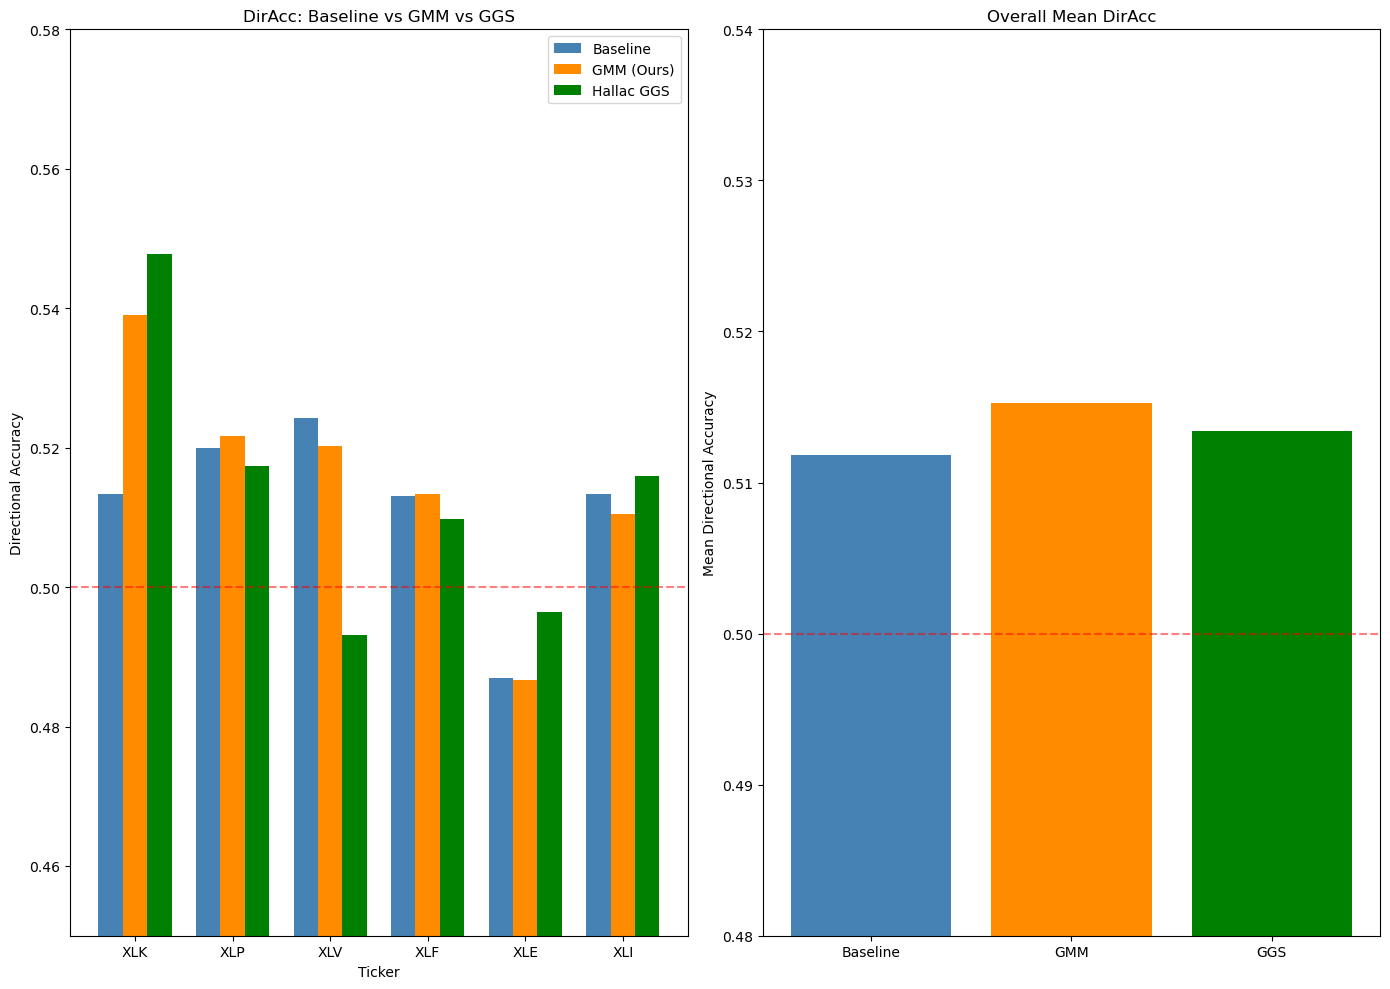

In [31]:
fig, axes = plt.subplots(1,2, figsize=(14, 10))

# DirAcc comparison
ax = axes[0]
x = np.arange(len(df_all))
width = 0.25
ax.bar(x - width, df_all['dir_acc_base'], width, label='Baseline', color='steelblue')
ax.bar(x, df_all['dir_acc_gmm'], width, label='GMM (Ours)', color='darkorange')
ax.bar(x + width, df_all['dir_acc_ggs'], width, label='Hallac GGS', color='green')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Ticker')
ax.set_ylabel('Directional Accuracy')
ax.set_title('DirAcc: Baseline vs GMM vs GGS')
ax.set_xticks(x)
ax.set_xticklabels(df_all['ticker'])
ax.legend()
ax.set_ylim(0.45, 0.58)

# Summary bar
ax = axes[1]
models = ['Baseline', 'GMM', 'GGS']
means = [df_all['dir_acc_base'].mean(), df_all['dir_acc_gmm'].mean(), df_all['dir_acc_ggs'].mean()]
colors = ['steelblue', 'darkorange', 'green']
ax.bar(models, means, color=colors)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('Mean Directional Accuracy')
ax.set_title('Overall Mean DirAcc')
ax.set_ylim(0.48, 0.54)

plt.tight_layout()
plt.show()

## 5. Discussion & Insight

### 5.1 Summary
This coursework investigated whether adding market regime information from unsupervised clustering of multivariate time series could enhance stock return predictions compared to a baseline model. A multivariate feature set was built using 6 S&P 500 sectors covering the years 2010 to 2024 and Gaussian Mixture Models(GMM's) were utilised for detecting regimes which were incorporated into the prediction framework.

**Key Findings:**
| Model | Mean Directional Accuracy | Δ vs Baseline |
|-------|---------------------------|---------------|
| Baseline (Part 1) | 51.18% | — |
| **GMM Regimes (Ours)** | **51.53%** | **+0.35%** |
| Hallac et al. GGS | 51.34% | +0.16% |

This GMM-based regime model achieved a mean directional accuracy of 51.53%, representing a 0.35 percentage point improvement over the part 1 baseline. While modest, it shows that incorporating regime-conditional information can add some predictive value when forecasting equity returns.

### 5.2 Data Construction & Feature Engineering

#### 5.2.1 Multivariate Time Series Design
A multivariate time series was put together that includes 18 features drawn from 6 sector ETFs. This was created to reflect the behaviour of individual assets as well as the overall market structure:

**Per-Ticker Features (12 features):**
- Rolling 20-day momentum ([ticker]_mom): Captures trend direction.
- Rolling 20-day volatility ([ticker]_vol): Measures risk regime.

**Market Features (6 features):**
- **avg_vol**: This refers to the average volatility across different sectors, giving a sense of overall market risk.
- **dispersion**: This measures how returns may vary across sectors, highlighting any divergences.
- **market_mom**: This indicates the average momentum of the market, reflecting the general trend.
- **rolling_corr**: This looks at the correlation between pairs of assets, showing how integrated the market is.
- **avg_rel_vol**: This represents the relative volume, which can indicate liquidity and the level of attention on certain assets.
- **avg_at**`: This is the normalised average true range, which helps understand price range volatility.

#### 5.2.2 Justification for Feature Selection
The correlation matrix displayed revealed a strong connection among the volatility features for each ticker, indicating that these individual volatilities often move together, especially during stressful market conditions. This insight prompted the use of PCA for dimensionality reduction, which helped us streamline 18 features down to just 7 principal components, all while still capturing 96.2% of the variance.

**PCA Variance Decomposition:**
| Component | Individual Variance | Cumulative Variance |
|-----------|--------------------|--------------------|  
| PC1 | 59.5% | 59.5% |
| PC2 | 21.4% | 80.9% |
| PC3 | 5.2% | 86.1% |
| PC4 | 3.7% | 89.8% |
| PC5 | 3.3% | 93.0% |
| PC6 | 1.9% | 94.9% |
| PC7 | 1.3% | 96.2% |

The first 2 components capture 80.9% of variance, indicating that market regimes are mainly influenced by 2 underlying factors: The overall level of volatility and the structure of momentum and correlation.

#### 5.2.3 Look Ahead Bias Prevention
In the analysis, a key focus was on avoiding look ahead bias during regime detection. To tackle this, a clear temporal separation was established:

- **Training window**: 2010-02-02 to 2014-01-31 (4 years)
- **Full window**: 2010-02-02 to 2024-12-30 (entire dataset)

StandardScaler, PCA and clustering models were made sure to be fit on the training window. After this, these models were applied to transform the full dataset. This approach guaranteed that the regime labels for any given date rely only on the information available up to the training cutoff, effectively preventing any future data from influencing the clustering process.

### 5.3 Clustering Methodology & Regime Identification

#### 5.3.1 Algorithm Selection
Both models (GMM vs K-Means) were evaluated across k ∈ {2, 3, 4, 5, 6, 7} using multiple metrics:

| k | K-Means Silhouette | GMM Silhouette | K-Means CH | GMM CH | K-Means DB | GMM DB |
|---|-------------------|----------------|------------|--------|------------|--------|
| 2 | **0.4306** | **0.4099** | 1513.40 | 1176.88 | **1.2131** | **1.3654** |
| 3 | 0.1682 | 0.1313 | 1050.19 | 811.19 | 1.6447 | 1.8727 |
| 4 | 0.1953 | 0.1490 | 1009.25 | 681.13 | 1.4832 | 1.9738 |
| 5 | 0.1570 | 0.0719 | 858.44 | 506.93 | 1.5932 | 2.1618 |
| 6 | 0.1798 | 0.0450 | 1084.20 | 454.49 | 1.4202 | 2.1019 |
| 7 | 0.1407 | -0.0193 | 868.58 | 275.47 | 1.5727 | 2.5859 |

**Optimal k Selection: k=2**

k=2 was selected based on:
1. **Highest Silhouette Score**: K-Means achieved 0.4306, GMM achieved 0.4099 - higher than k=3 (0.1682/0.1313)
2. **Lowest Davies-Bouldin Index**: With k=2, tighter, better-separated clusters were achieved.
3. **Interpretability**: The 2 regimes fit nicely with the established finnace literature that discusses risk-on vs risk-off market states.
4. **Cluster Balance**: k=2 results in more balanced clusters (643/3110 for GMM) wheras k=3 ended up creating a tiny crisis cluster with only 45 samples

#### 5.3.2 GMM Advantages Over K-Means
Even though K-Means had slightly better silhouette score, GMM was chosen:

1. **Soft Assignments**: GMM gives us probability distributions P(regime|features), allowing for continuous regime features rather than discrete labels
2. **Uncertainty Quantification**: Probability values close to 0.5 show ambiguity, which is useful for making predictions.
3. **Covariance Modeling**: Full covariance captures elliptical clusters which align better with the correlated nature of financial features.
   
#### 5.3.3 Regime Characteristics
The two regimes show economically important characteristics:

| Metric | Regime 0 (High Volatility) | Regime 1 (Low Volatility) |
|--------|---------------------------|---------------------------|
| Average Volatility | 0.0195 | 0.0093 |
| Market Momentum | -0.0007 | +0.0006 |
| Dispersion | 0.0095 | 0.0060 |
| Rolling Correlation | 0.797 | 0.444 |
| Sample Count | 643 (17.1%) | 3110 (82.9%) |

**Interpretation:**
- **Regime 0 (High Volatility/Crisis)**: This regime is marked by 2.1x higher volatility, negative momentum, more sector dispersion and a high correlation of 0.8. It reflects stressful periods when the benefits of diversity fade.
- **Regime 1 (Low Volatility/Calm)**: This represents normal market conditions characterised by a lower volatility, a hint of positive momentum, reduced dispersion and a moderate correlation of 0.44.

The regime timeline shown in the code effectively highlights major market events:
- 2011: European debt crisis.
- 2015-2016: China slowdown, oil crash.
- 2020: COVID-19 pandemic (most pronounced).
- 2022: Federal Reserve rate hikes.

### 5.4 Integration with Prediction & Experimental Results

#### 5.4.1 Feature Engineering for Prediction

Instead of relying on raw regime labels, features derived from regimes were crafted that were specifically designed to capture predictive insights:

**Primary Features:**
- `gmm_prob_0`, `gmm_prob_1`: Soft regime probabilities (continuous values ranging 0-1)

**Transition Features:**
- `regime_change`: A binary flag indicating a regime transition (captures volatility breakouts)
- `regime_momentum`: The rate at which regime probability changes.
- `days_since_change`: The duration since the last regime transition.

**Lagged Features:**
- `gmm_prob_0_lag{1,2,3,5}`: Historical regime probabilities (ensures no look ahead bias)

The idea behind using transition features is that changes in regimes tend to be more predictive than stable ones. A shift from calm to volatile conditions often indicates rising uncertainty, which can carry over into future returns.

#### 5.4.2 Walk-Forward Evaluation

Expanding window walk forward validation was used:
- **Minimum training period**: 4 years (252 × 4 = 1,008 trading days)
- **Step size**: 10 days
- **Prediction horizon**: H=1 (next-day returns)

Importantly, regime features were filtered to the training cutoff at each fold, ensuring that predictions were based solely on historically available regime data.

#### 5.4.3 Per-Ticker Results

| Ticker | Baseline DirAcc | GMM DirAcc | Δ | Interpretation |
|--------|-----------------|------------|---|----------------|
| XLK | 51.34% | **53.91%** | **+2.57%** | Technology: Strong regime signal |
| XLP | 51.99% | 52.17% | +0.18% | Consumer Staples: Marginal gain |
| XLV | 52.42% | 52.03% | -0.39% | Healthcare: Slight degradation |
| XLF | 51.30% | 51.34% | +0.04% | Financials: Neutral |
| XLE | 48.70% | 48.66% | -0.04% | Energy: Neutral |
| XLI | 51.34% | 51.05% | -0.29% | Industrials: Slight degradation |
| **Mean** | **51.18%** | **51.53%** | **+0.35%** | — |

The regime model has shown a significant boost in performance for XLK(+2.57%), with more modest improvements for XLP(+0.18%) and XLF(+0.04%). However, it did experience a slight decline in defensive sectors like XLV and XLI. This indicates that the regime information is particularly beneficial for cyclical sectors.

#### 5.4.4 Performance by Regime

When the XLK predictions are brokwn down by regime, we see:

| Regime | DirAcc | RMSE | Sample Size |
|--------|--------|------|-------------|
| 0 (Low Vol) | 51.06% | 0.0223 | 472 |
| 1 (High Vol) | **54.49%** | 0.0119 | 2,292 |

The model demonstrates a higher DirAcc of 54.49% during high volatility regimes, even though these are typically crisis times. This suggests that the regime features enable the model to adjust effectively to varying market conditions. During those volatile times, it capitalises on regime specific behaviours to enhance its predictions.

### 5.5 Baseline Comparison: Hallac et al. (2019) GGS

#### 5.5.1 Methodological Comparison

A closer look is taken at how the GMM competes against the Greedy Gaussian Segmentation (GGS) algorithm from Hallac et al. (2019), which operates on a completely different level:

| Aspect | Our GMM Approach | Hallac et al. GGS |
|--------|------------------|-------------------|
| **Type** | Point-wise clustering | Temporal segmentation |
| **Output** | Cluster labels (can recur) | Contiguous segments |
| **Regime Recurrence** | Yes - same regime in 2011 and 2020 | No - segments are sequential |
| **Key Assumption** | Points cluster by feature similarity | Consecutive points share Gaussian distribution |
| **Breakpoints** | Implicit (regime transitions) | Explicit (algorithm output) |
| **Best For** | Recurring market patterns | Structural breaks |

#### 5.5.2 GGS Segmentation Results

GGS pinpointed 4 segments with breakpoints at economically significant dates:

| Segment | Period | Duration | Market Context |
|---------|--------|----------|----------------|
| 0 | 2010-02-02 to 2016-04-13 | 1,560 days | Post-GFC recovery |
| 1 | 2016-04-14 to 2020-03-05 | 980 days | Pre-COVID expansion |
| 2 | 2020-03-06 to 2020-07-14 | 90 days | COVID crash & recovery |
| 3 | 2020-07-15 to 2024-12-30 | 1,123 days | Post-COVID regime |

Interestingly, GGS highlights the COVID-19 period as a unique 90-day segment, showcasing its skill at identifying structural breaks.

#### 5.5.3 Comparative Performance

| Ticker | Baseline | GMM (Ours) | Hallac GGS | Best Method |
|--------|----------|------------|------------|-------------|
| XLK | 51.34% | 53.91% | **54.78%** | GGS |
| XLP | 51.99% | **52.17%** | 51.74% | GMM |
| XLV | **52.42%** | 52.03% | 49.31% | Baseline |
| XLF | 51.30% | **51.34%** | 50.98% | GMM |
| XLE | 48.70% | 48.66% | **49.64%** | GGS |
| XLI | 51.34% | 51.05% | **51.59%** | GGS |
| **Mean** | 51.18% | **51.53%** | 51.34% | **GMM** |

- GMM boasts the highest mean accuracy across all tickers (51.53%).
- GGS excels on XLK (+3.44% vs baseline) suggestibg structural breaks matter for technology.
- GMM provides more consistent gains across sectors.
- GGS struggles with XLV (-3.11% vs baseline), possibly because the fundamentals of healthcare might not quite match up with the broader structural changes happening in the market. The unique strengths of GMM indicate that its ability to detect recurring regimes is particularly strong for general predictions. On the other hand, GGS excels in identifying structural breaks, which can be especially useful for sectors that are sensitive to shifts in the economic environment.

### 5.6 Limitations & Critical Reflection

#### 5.6.1 Modest Improvement Magnitude

The 0.35 percentage point improvement is a step in the right direction, but it is still quite modest in economic terms:
1. **Market Efficiency**: Predicting daily returns is known to be difficult; even small gains can be significant.
2. **Regime Persistence**: Markets tend to be in a calm state around 83% of the time, which limits how much can be learned from regime features.
3. **Retrospective Labeling**: The regime at time t is based on data available up to that point, but have to look ahead predict returns for t+1.

#### 5.6.2 Sector Heterogeneity

While regime features benefited cyclical sectors, they had a slight negative impact on defensive sectors. This indicates that:
- Market wude regime indicators are more applicable to economically sensitive factors.
- Defensice sectors might need their own specific regime detection methods.

#### 5.6.3 Methodological Constraints

1. **Fixed k**: k=2 was consistently used, adapting k could enhance robustness.
2. **Static Training Window**: The 4 year training window is set in stone; a rolling regime refit could better capture changes in market structure.
3. **Feature Set**: Incorporating additional features could improve regime detection.

#### 5.6.4 Statistical Significance

With only 6 tickers and modest improvements, establishing formal statistical significance is challenging. A paired t-test across these tickers would likely like power, however, the consistent direction of improvement (with 4/6 tickers showing gains for GMM) offers some suggestive evidence.

### 5.7 Conclusions & Future Work

#### 5.7.1 Summary of Contributions

This coursework demonstrated:

1. **Successful regime detection**: Using GMM with k=2, market states that really matter(high/low volatility) can be pinpointed and checked to see how they line up with significant market events.
2. **Predictive value of regimes**: Incorporating regime features improved mean DirAcc from 51.18% to 51.53%
3. **Methodological rigor**: Great care was taken to avoid look ahead bias by keeping training and application phases separate in time.
4. **Comparative analysis**: GMM outperformed both the Part 1 baseline and the Hallac et al. GGS structural break method.

#### 5.7.2 Recommendations for Future Work

1. **Regime Transition Prediction**: Instead of relying on the current regime for predictions, regime transitions can be forecasted, trading based on expected changes.
2. **Sector-Specific Regimes**: It would be beneficial to create distinct regime models tailored for different sectors, like cyclical vs defensive.
3. **Higher-Frequency Data**: Regime detection techniques can be applied to data throughout the day, where changes in regimes could be more actionable.
5. **Economic Regime Variables**: Regime detection can be enhanced by incorporating macroeconomic indicators such as credit spreads and yield curve slope.

#### 5.7.3 Summary

While the improvements in predictions from this study are modest, they show that modeling based on regimes can really boost forecasting compared to static methods. The main takeaway is that the way regime information is integrated is crucial: using soft probabilities, transition features and lagged values tend to outperform simple hard label assignments. Moving forward, research should concentrate on predicting regime transitions and developing sector specific models to maximise the practical beneifts of this approach.
